🚀 Initializing Relationship Analyzer...
📂 Loading Excel sheets...
✅ Loaded 28377 specifications
✅ Loaded 3744 SMART assessments
✅ Loaded 33641 verification plans
✅ Loaded 25941 activities

🚀 Starting complete relationship analysis for:
   http://data.tennet.eu/id/4d327c1b-328d-3511-b344-32ce09710ede
🔍 Finding specification details for: http://data.tennet.eu/id/4d327c1b-328d-3511-b344-32ce09710ede
✅ Found 1 specification entries:
   Entry 1: AC-verdeler, markering aarding (AM-Req-3825.03)
🌳 Building complete specification hierarchy...
   👆 Finding parent relationships...
   👴 Finding grandparent relationships...
   👇 Finding child relationships...
   👶 Finding grandchild relationships...
   👫 Finding sibling relationships...
✅ Complete hierarchy mapped:
   📊 Parents: 0 (Direct: 0, Derived: 0)
   📊 Children: 4 (Direct: 0, Derived: 4)
   📊 Siblings: 0
   📊 Grandparents: 0
   📊 Grandchildren: 0
   📊 Total family members: 4
   📊 Hierarchy depth: 0 levels up, 1 levels down
🎯 Finding existing

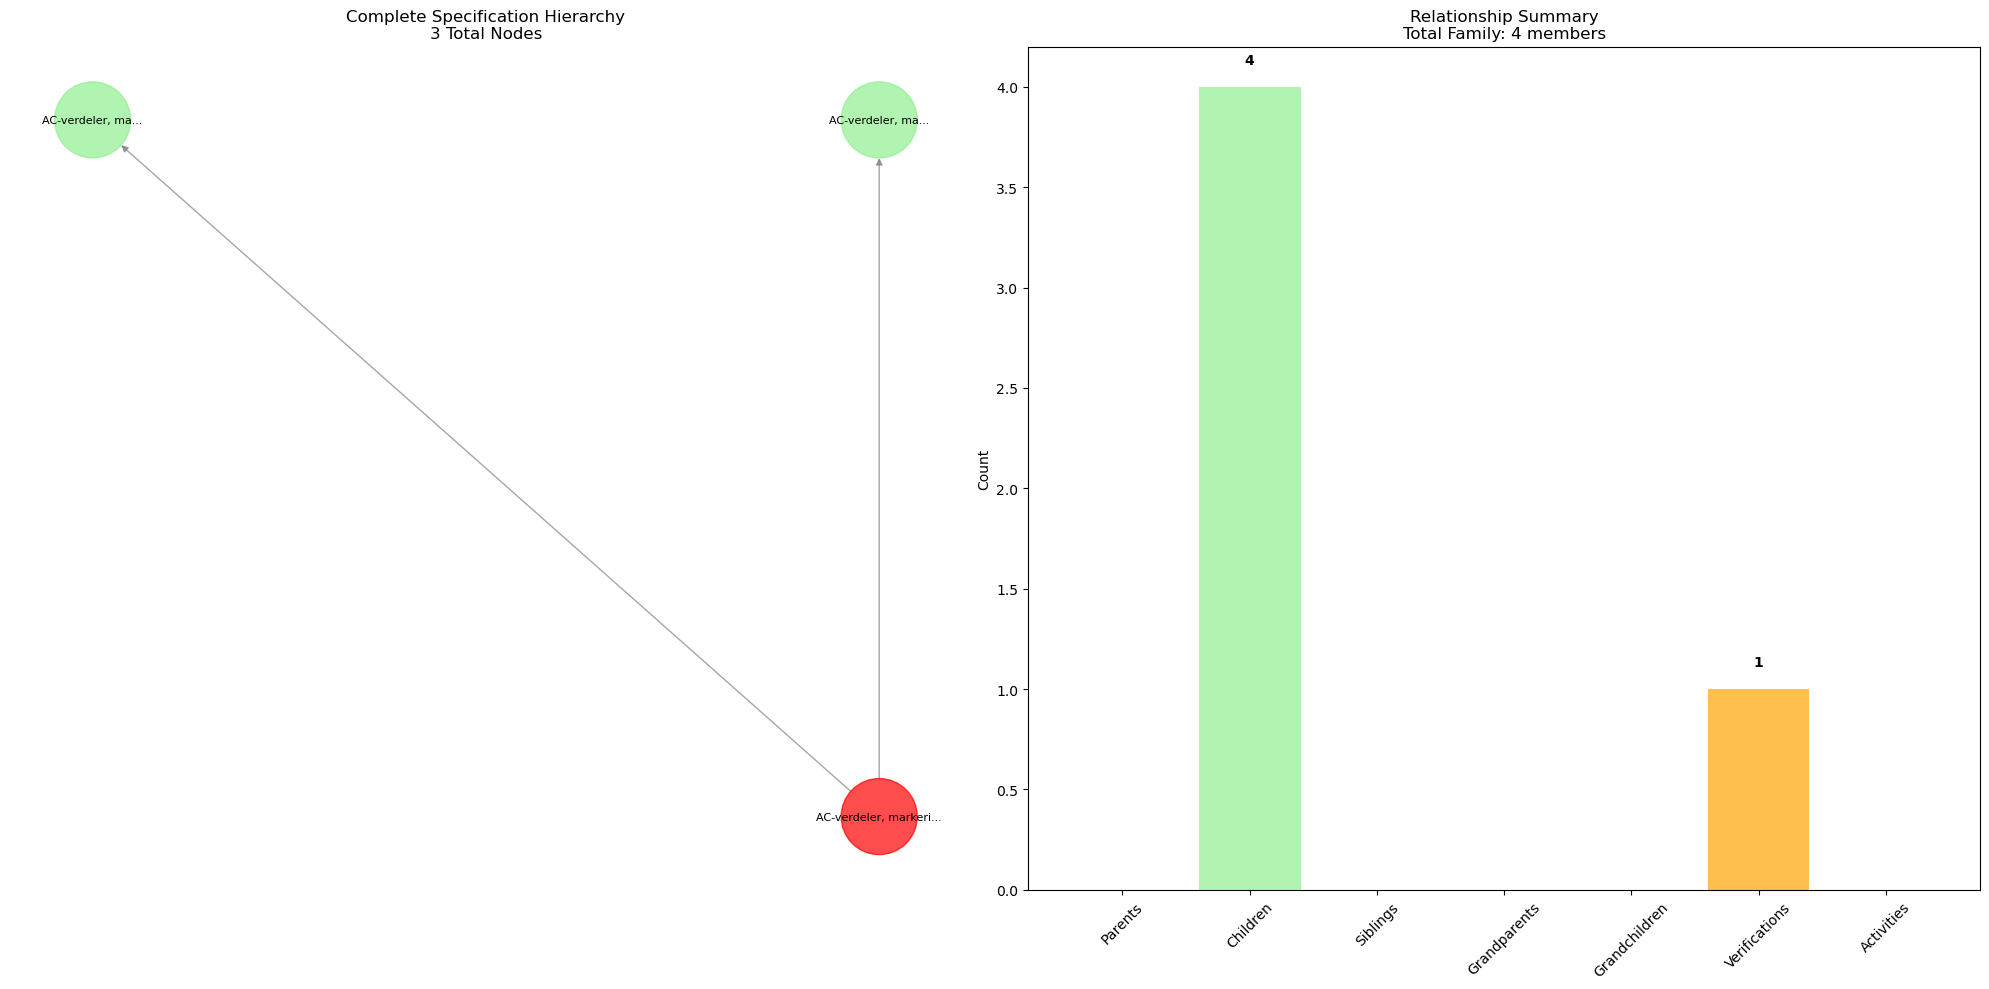


✅ Complete relationship analysis finished!


In [ ]:
"""
Complete Relationship Set Analyzer for Omexom Database
Focuses on mapping all parent-child relationships and connections across tables
"""

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Any, Optional
import warnings
warnings.filterwarnings('ignore')

class RelationshipAnalyzer:
    """
    Complete relationship analyzer for specification hierarchies
    """
    
    def __init__(self, excel_file_path: str):
        """Initialize analyzer with Excel file path"""
        self.excel_file_path = excel_file_path
        self.specs_df = None
        self.smart_df = None
        self.verification_df = None
        self.activities_df = None
        self.load_data()
    
    def load_data(self):
        """Load all Excel sheets into DataFrames"""
        print("📂 Loading Excel sheets...")
        try:
            self.specs_df = pd.read_excel(self.excel_file_path, sheet_name='Specifications')
            self.smart_df = pd.read_excel(self.excel_file_path, sheet_name='Smart assessment')
            self.verification_df = pd.read_excel(self.excel_file_path, sheet_name='Verificatieplan')
            self.activities_df = pd.read_excel(self.excel_file_path, sheet_name='Activiteiten, objecten en ruimt')
            
            print(f"✅ Loaded {len(self.specs_df)} specifications")
            print(f"✅ Loaded {len(self.smart_df)} SMART assessments")
            print(f"✅ Loaded {len(self.verification_df)} verification plans")
            print(f"✅ Loaded {len(self.activities_df)} activities")
            
        except Exception as e:
            print(f"❌ Error loading data: {e}")
            raise
    
    def find_specification_details(self, target_uri: str) -> Dict[str, Any]:
        """Find complete specification details for target URI"""
        print(f"🔍 Finding specification details for: {target_uri}")
        
        specs = self.specs_df[self.specs_df['ProjectSpecificationUri'] == target_uri]
        
        if specs.empty:
            return {"error": f"Specification {target_uri} not found", "found": False}
        
        # Get all entries (in case of duplicates)
        all_specs = specs.to_dict('records')
        
        print(f"✅ Found {len(all_specs)} specification entries:")
        for i, spec in enumerate(all_specs, 1):
            print(f"   Entry {i}: {spec.get('ProjectSpecificationName', 'Unknown')} ({spec.get('ProjectSpecificationCode', 'Unknown')})")
        
        return {"specifications": all_specs, "found": True, "count": len(all_specs)}
    
    def build_complete_hierarchy(self, target_uri: str) -> Dict[str, Any]:
        """Build complete parent-child hierarchy recursively"""
        print("🌳 Building complete specification hierarchy...")
        
        hierarchy = {
            "target_uri": target_uri,
            "direct_parents": [],
            "derived_parents": [],
            "all_parents": [],
            "direct_children": [],
            "derived_children": [],
            "all_children": [],
            "siblings": [],
            "grandparents": [],
            "grandchildren": [],
            "levels_up": 0,
            "levels_down": 0,
            "total_family": 0
        }
        
        # === FIND PARENTS ===
        print("   👆 Finding parent relationships...")
        
        # Direct parents (isWholeOfParentProjectSpecificationUri)
        target_specs = self.specs_df[self.specs_df['ProjectSpecificationUri'] == target_uri]
        if not target_specs.empty:
            for _, spec in target_specs.iterrows():
                parent_uri = spec.get('isWholeOfParentProjectSpecificationUri')
                if pd.notna(parent_uri) and parent_uri != "":
                    parent_specs = self.specs_df[self.specs_df['ProjectSpecificationUri'] == parent_uri]
                    if not parent_specs.empty:
                        parent_info = parent_specs.iloc[0].to_dict()
                        parent_info['relationship_type'] = 'whole_of_parent'
                        hierarchy["direct_parents"].append(parent_info)
                        hierarchy["all_parents"].append(parent_info)
                
                # Derivation parents (IsDerivedFrom)
                derived_from = spec.get('IsDerivedFrom')
                if pd.notna(derived_from) and derived_from != "":
                    derived_specs = self.specs_df[self.specs_df['ProjectSpecificationUri'] == derived_from]
                    if not derived_specs.empty:
                        derived_info = derived_specs.iloc[0].to_dict()
                        derived_info['relationship_type'] = 'derived_from'
                        hierarchy["derived_parents"].append(derived_info)
                        if derived_info not in hierarchy["all_parents"]:
                            hierarchy["all_parents"].append(derived_info)
        
        # === FIND GRANDPARENTS (Parents of Parents) ===
        print("   👴 Finding grandparent relationships...")
        for parent in hierarchy["all_parents"]:
            parent_uri = parent['ProjectSpecificationUri']
            grandparent_uri = parent.get('isWholeOfParentProjectSpecificationUri')
            if pd.notna(grandparent_uri) and grandparent_uri != "":
                grandparent_specs = self.specs_df[self.specs_df['ProjectSpecificationUri'] == grandparent_uri]
                if not grandparent_specs.empty:
                    grandparent_info = grandparent_specs.iloc[0].to_dict()
                    grandparent_info['via_parent'] = parent.get('ProjectSpecificationName', 'Unknown')
                    hierarchy["grandparents"].append(grandparent_info)
                    hierarchy["levels_up"] = max(hierarchy["levels_up"], 2)
        
        if hierarchy["all_parents"]:
            hierarchy["levels_up"] = max(hierarchy["levels_up"], 1)
        
        # === FIND CHILDREN ===
        print("   👇 Finding child relationships...")
        
        # Direct children (where target is parent)
        direct_children = self.specs_df[
            self.specs_df['isWholeOfParentProjectSpecificationUri'] == target_uri
        ]
        for _, child in direct_children.iterrows():
            child_info = child.to_dict()
            child_info['relationship_type'] = 'whole_of_child'
            hierarchy["direct_children"].append(child_info)
            hierarchy["all_children"].append(child_info)
        
        # Derived children (where target is derivation source)
        derived_children = self.specs_df[
            self.specs_df['IsDerivedFrom'] == target_uri
        ]
        for _, child in derived_children.iterrows():
            child_info = child.to_dict()
            child_info['relationship_type'] = 'derived_child'
            hierarchy["derived_children"].append(child_info)
            if child_info not in hierarchy["all_children"]:
                hierarchy["all_children"].append(child_info)
        
        # === FIND GRANDCHILDREN ===
        print("   👶 Finding grandchild relationships...")
        for child in hierarchy["all_children"]:
            child_uri = child['ProjectSpecificationUri']
            
            # Find children of this child
            grandchildren_direct = self.specs_df[
                self.specs_df['isWholeOfParentProjectSpecificationUri'] == child_uri
            ]
            grandchildren_derived = self.specs_df[
                self.specs_df['IsDerivedFrom'] == child_uri
            ]
            
            for _, grandchild in grandchildren_direct.iterrows():
                grandchild_info = grandchild.to_dict()
                grandchild_info['via_child'] = child.get('ProjectSpecificationName', 'Unknown')
                grandchild_info['relationship_type'] = 'grandchild_direct'
                hierarchy["grandchildren"].append(grandchild_info)
            
            for _, grandchild in grandchildren_derived.iterrows():
                grandchild_info = grandchild.to_dict()
                grandchild_info['via_child'] = child.get('ProjectSpecificationName', 'Unknown')
                grandchild_info['relationship_type'] = 'grandchild_derived'
                if grandchild_info not in hierarchy["grandchildren"]:
                    hierarchy["grandchildren"].append(grandchild_info)
        
        if hierarchy["all_children"]:
            hierarchy["levels_down"] = max(hierarchy["levels_down"], 1)
        if hierarchy["grandchildren"]:
            hierarchy["levels_down"] = max(hierarchy["levels_down"], 2)
        
        # === FIND SIBLINGS ===
        print("   👫 Finding sibling relationships...")
        if hierarchy["all_parents"]:
            for parent in hierarchy["all_parents"]:
                parent_uri = parent['ProjectSpecificationUri']
                
                # Find other children of this parent
                siblings_direct = self.specs_df[
                    (self.specs_df['isWholeOfParentProjectSpecificationUri'] == parent_uri) &
                    (self.specs_df['ProjectSpecificationUri'] != target_uri)
                ]
                siblings_derived = self.specs_df[
                    (self.specs_df['IsDerivedFrom'] == parent_uri) &
                    (self.specs_df['ProjectSpecificationUri'] != target_uri)
                ]
                
                for _, sibling in siblings_direct.iterrows():
                    sibling_info = sibling.to_dict()
                    sibling_info['shared_parent'] = parent.get('ProjectSpecificationName', 'Unknown')
                    sibling_info['relationship_type'] = 'sibling_direct'
                    hierarchy["siblings"].append(sibling_info)
                
                for _, sibling in siblings_derived.iterrows():
                    sibling_info = sibling.to_dict()
                    sibling_info['shared_parent'] = parent.get('ProjectSpecificationName', 'Unknown')
                    sibling_info['relationship_type'] = 'sibling_derived'
                    if sibling_info not in hierarchy["siblings"]:
                        hierarchy["siblings"].append(sibling_info)
        
        # Calculate totals
        hierarchy["total_family"] = (
            len(hierarchy["all_parents"]) + 
            len(hierarchy["all_children"]) + 
            len(hierarchy["siblings"]) + 
            len(hierarchy["grandparents"]) + 
            len(hierarchy["grandchildren"])
        )
        
        print(f"✅ Complete hierarchy mapped:")
        print(f"   📊 Parents: {len(hierarchy['all_parents'])} (Direct: {len(hierarchy['direct_parents'])}, Derived: {len(hierarchy['derived_parents'])})")
        print(f"   📊 Children: {len(hierarchy['all_children'])} (Direct: {len(hierarchy['direct_children'])}, Derived: {len(hierarchy['derived_children'])})")
        print(f"   📊 Siblings: {len(hierarchy['siblings'])}")
        print(f"   📊 Grandparents: {len(hierarchy['grandparents'])}")
        print(f"   📊 Grandchildren: {len(hierarchy['grandchildren'])}")
        print(f"   📊 Total family members: {hierarchy['total_family']}")
        print(f"   📊 Hierarchy depth: {hierarchy['levels_up']} levels up, {hierarchy['levels_down']} levels down")
        
        return hierarchy
    
    def find_smart_assessment(self, target_uri: str) -> Dict[str, Any]:
        """Find existing SMART assessment from database"""
        print("🎯 Finding existing SMART assessment...")
        
        smart_entry = self.smart_df[self.smart_df['SpecificationURI'] == target_uri]
        
        if smart_entry.empty:
            print("❌ No SMART assessment found in database")
            return {"found": False, "error": "No SMART assessment found"}
        
        assessment = smart_entry.iloc[0].to_dict()
        smart_status = assessment.get('Smart/ niet smart', 'Unknown')
        smart_ref = assessment.get('SpecificationSMART_ref', 'Unknown')
        
        print(f"✅ Found SMART assessment: {smart_status}")
        print(f"   Assessment Reference: {smart_ref}")
        
        return {"found": True, "assessment": assessment, "status": smart_status, "reference": smart_ref}
    
    def find_all_connections(self, target_uri: str, hierarchy: Dict[str, Any]) -> Dict[str, Any]:
        """Find all connections across verification plans and activities"""
        print("🔗 Finding all cross-table connections...")
        
        connections = {
            "verification_plans": [],
            "related_activities": [],
            "hierarchy_connections": {
                "parent_verifications": [],
                "child_verifications": [],
                "parent_activities": [],
                "child_activities": []
            }
        }
        
        # Collect all related URIs
        all_related_uris = [target_uri]
        all_related_uris.extend([p['ProjectSpecificationUri'] for p in hierarchy.get('all_parents', [])])
        all_related_uris.extend([c['ProjectSpecificationUri'] for c in hierarchy.get('all_children', [])])
        all_related_uris.extend([s['ProjectSpecificationUri'] for s in hierarchy.get('siblings', [])[:5]])  # Limit siblings
        
        # === VERIFICATION PLANS ===
        print("   ✅ Finding verification plans...")
        verification_plans = self.verification_df[
            self.verification_df['ProjectSpecificationUri'].isin(all_related_uris)
        ]
        
        for _, plan in verification_plans.iterrows():
            plan_info = plan.to_dict()
            plan_uri = plan_info['ProjectSpecificationUri']
            
            # Categorize relationship
            if plan_uri == target_uri:
                plan_info['relationship'] = 'target'
                connections["verification_plans"].append(plan_info)
            elif plan_uri in [p['ProjectSpecificationUri'] for p in hierarchy.get('all_parents', [])]:
                plan_info['relationship'] = 'parent'
                connections["hierarchy_connections"]["parent_verifications"].append(plan_info)
            elif plan_uri in [c['ProjectSpecificationUri'] for c in hierarchy.get('all_children', [])]:
                plan_info['relationship'] = 'child'
                connections["hierarchy_connections"]["child_verifications"].append(plan_info)
            else:
                plan_info['relationship'] = 'sibling'
                connections["verification_plans"].append(plan_info)
        
        # === ACTIVITIES ===
        print("   🔄 Finding related activities...")
        activities = self.activities_df[
            self.activities_df['ProjectSpecificationUri'].isin(all_related_uris)
        ]
        
        for _, activity in activities.iterrows():
            activity_info = activity.to_dict()
            activity_uri = activity_info['ProjectSpecificationUri']
            
            # Categorize relationship
            if activity_uri == target_uri:
                activity_info['relationship'] = 'target'
                connections["related_activities"].append(activity_info)
            elif activity_uri in [p['ProjectSpecificationUri'] for p in hierarchy.get('all_parents', [])]:
                activity_info['relationship'] = 'parent'
                connections["hierarchy_connections"]["parent_activities"].append(activity_info)
            elif activity_uri in [c['ProjectSpecificationUri'] for c in hierarchy.get('all_children', [])]:
                activity_info['relationship'] = 'child'
                connections["hierarchy_connections"]["child_activities"].append(activity_info)
            else:
                activity_info['relationship'] = 'sibling'
                connections["related_activities"].append(activity_info)
        
        # Summary counts
        total_verifications = (
            len(connections["verification_plans"]) + 
            len(connections["hierarchy_connections"]["parent_verifications"]) + 
            len(connections["hierarchy_connections"]["child_verifications"])
        )
        
        total_activities = (
            len(connections["related_activities"]) + 
            len(connections["hierarchy_connections"]["parent_activities"]) + 
            len(connections["hierarchy_connections"]["child_activities"])
        )
        
        print(f"✅ Found {total_verifications} total verification plans")
        print(f"   - Target: {len(connections['verification_plans'])}")
        print(f"   - Parents: {len(connections['hierarchy_connections']['parent_verifications'])}")
        print(f"   - Children: {len(connections['hierarchy_connections']['child_verifications'])}")
        
        print(f"✅ Found {total_activities} total activities")
        print(f"   - Target: {len(connections['related_activities'])}")
        print(f"   - Parents: {len(connections['hierarchy_connections']['parent_activities'])}")
        print(f"   - Children: {len(connections['hierarchy_connections']['child_activities'])}")
        
        return connections
    
    def generate_complete_relationship_report(self, target_uri: str) -> Dict[str, Any]:
        """Generate complete relationship analysis report"""
        print(f"\n🚀 Starting complete relationship analysis for:")
        print(f"   {target_uri}")
        print("="*80)
        
        # Get specification details
        spec_result = self.find_specification_details(target_uri)
        if not spec_result.get("found", False):
            return spec_result
        
        # Build complete hierarchy
        hierarchy = self.build_complete_hierarchy(target_uri)
        
        # Find SMART assessment
        smart_result = self.find_smart_assessment(target_uri)
        
        # Find all connections
        connections = self.find_all_connections(target_uri, hierarchy)
        
        # Compile report
        report = {
            "target_uri": target_uri,
            "specifications": spec_result["specifications"],
            "hierarchy": hierarchy,
            "smart_assessment": smart_result,
            "connections": connections,
            "summary": self._generate_relationship_summary(spec_result, hierarchy, smart_result, connections)
        }
        
        return report
    
    def _generate_relationship_summary(self, spec_result: Dict, hierarchy: Dict, smart_result: Dict, connections: Dict) -> Dict[str, Any]:
        """Generate relationship summary"""
        return {
            "specification_name": spec_result["specifications"][0].get("ProjectSpecificationName", "Unknown"),
            "specification_code": spec_result["specifications"][0].get("ProjectSpecificationCode", "Unknown"),
            "specification_entries": len(spec_result["specifications"]),
            "smart_status": smart_result.get("status", "Not assessed"),
            "hierarchy_summary": {
                "total_family_members": hierarchy["total_family"],
                "parents": len(hierarchy["all_parents"]),
                "children": len(hierarchy["all_children"]),
                "siblings": len(hierarchy["siblings"]),
                "grandparents": len(hierarchy["grandparents"]),
                "grandchildren": len(hierarchy["grandchildren"]),
                "levels_up": hierarchy["levels_up"],
                "levels_down": hierarchy["levels_down"]
            },
            "connection_summary": {
                "total_verifications": len(connections["verification_plans"]) + 
                                     len(connections["hierarchy_connections"]["parent_verifications"]) + 
                                     len(connections["hierarchy_connections"]["child_verifications"]),
                "total_activities": len(connections["related_activities"]) + 
                                  len(connections["hierarchy_connections"]["parent_activities"]) + 
                                  len(connections["hierarchy_connections"]["child_activities"]),
                "direct_verifications": len(connections["verification_plans"]),
                "direct_activities": len(connections["related_activities"])
            }
        }
    
    def print_complete_relationship_report(self, report: Dict[str, Any]):
        """Print formatted complete relationship report"""
        print("\n" + "="*80)
        print("📋 COMPLETE RELATIONSHIP ANALYSIS REPORT")
        print("="*80)
        
        summary = report["summary"]
        hierarchy = report["hierarchy"]
        connections = report["connections"]
        
        # Header
        print(f"\n🎯 TARGET SPECIFICATION:")
        print(f"   Name: {summary['specification_name']}")
        print(f"   Code: {summary['specification_code']}")
        print(f"   URI: {report['target_uri']}")
        print(f"   Database Entries: {summary['specification_entries']}")
        print(f"   SMART Status: {summary['smart_status']}")
        
        # Hierarchy Overview
        print(f"\n🌳 HIERARCHY OVERVIEW:")
        hs = summary["hierarchy_summary"]
        print(f"   Total Family Members: {hs['total_family_members']}")
        print(f"   Hierarchy Depth: {hs['levels_up']} levels up, {hs['levels_down']} levels down")
        print(f"   Direct Relations: {hs['parents']} parents, {hs['children']} children, {hs['siblings']} siblings")
        print(f"   Extended Relations: {hs['grandparents']} grandparents, {hs['grandchildren']} grandchildren")
        
        # Connections Overview
        print(f"\n🔗 CONNECTIONS OVERVIEW:")
        cs = summary["connection_summary"]
        print(f"   Total Verification Plans: {cs['total_verifications']} (Direct: {cs['direct_verifications']})")
        print(f"   Total Related Activities: {cs['total_activities']} (Direct: {cs['direct_activities']})")
        
        # Detailed Hierarchy
        if hierarchy["all_parents"]:
            print(f"\n👆 PARENT SPECIFICATIONS ({len(hierarchy['all_parents'])}):")
            for i, parent in enumerate(hierarchy["all_parents"], 1):
                rel_type = parent.get('relationship_type', 'unknown')
                print(f"   {i}. [{rel_type.upper()}] {parent.get('ProjectSpecificationName', 'Unknown')}")
                print(f"      Code: {parent.get('ProjectSpecificationCode', 'Unknown')}")
                print(f"      URI: {parent.get('ProjectSpecificationUri', 'Unknown')}")
                if parent.get('ProjectSpecificationText'):
                    print(f"      Text: {parent['ProjectSpecificationText'][:100]}...")
                print()
        
        if hierarchy["grandparents"]:
            print(f"\n👴 GRANDPARENT SPECIFICATIONS ({len(hierarchy['grandparents'])}):")
            for i, gp in enumerate(hierarchy["grandparents"], 1):
                print(f"   {i}. {gp.get('ProjectSpecificationName', 'Unknown')} (via {gp.get('via_parent', 'Unknown')})")
                print(f"      Code: {gp.get('ProjectSpecificationCode', 'Unknown')}")
                print()
        
        if hierarchy["all_children"]:
            print(f"\n👇 CHILD SPECIFICATIONS ({len(hierarchy['all_children'])}):")
            for i, child in enumerate(hierarchy["all_children"], 1):
                rel_type = child.get('relationship_type', 'unknown')
                print(f"   {i}. [{rel_type.upper()}] {child.get('ProjectSpecificationName', 'Unknown')}")
                print(f"      Code: {child.get('ProjectSpecificationCode', 'Unknown')}")
                print(f"      URI: {child.get('ProjectSpecificationUri', 'Unknown')}")
                if child.get('ProjectSpecificationText'):
                    print(f"      Text: {child['ProjectSpecificationText'][:100]}...")
                print()
        
        if hierarchy["grandchildren"]:
            print(f"\n👶 GRANDCHILD SPECIFICATIONS ({len(hierarchy['grandchildren'])}):")
            for i, gc in enumerate(hierarchy["grandchildren"], 1):
                print(f"   {i}. {gc.get('ProjectSpecificationName', 'Unknown')} (via {gc.get('via_child', 'Unknown')})")
                print(f"      Code: {gc.get('ProjectSpecificationCode', 'Unknown')}")
                print()
        
        if hierarchy["siblings"]:
            print(f"\n👫 SIBLING SPECIFICATIONS ({len(hierarchy['siblings'])}):")
            for i, sibling in enumerate(hierarchy["siblings"][:10], 1):  # Limit to 10
                print(f"   {i}. {sibling.get('ProjectSpecificationName', 'Unknown')}")
                print(f"      Code: {sibling.get('ProjectSpecificationCode', 'Unknown')}")
                print(f"      Shared Parent: {sibling.get('shared_parent', 'Unknown')}")
                print()
        
        # Verification Plans
        if connections["verification_plans"]:
            print(f"\n✅ DIRECT VERIFICATION PLANS ({len(connections['verification_plans'])}):")
            for i, plan in enumerate(connections["verification_plans"], 1):
                print(f"   {i}. Phase: {plan.get('Phase', 'Unknown')}")
                print(f"      Method: {plan.get('VerificationMethod', 'Unknown')}")
                print(f"      Discipline: {plan.get('Discipline', 'Unknown')}")
                print()
        
        # Parent/Child Verifications
        parent_verifs = connections["hierarchy_connections"]["parent_verifications"]
        child_verifs = connections["hierarchy_connections"]["child_verifications"]
        
        if parent_verifs:
            print(f"\n✅ PARENT VERIFICATION PLANS ({len(parent_verifs)}):")
            for i, plan in enumerate(parent_verifs[:5], 1):
                print(f"   {i}. Phase: {plan.get('Phase', 'Unknown')} | Method: {plan.get('VerificationMethod', 'Unknown')}")
        
        if child_verifs:
            print(f"\n✅ CHILD VERIFICATION PLANS ({len(child_verifs)}):")
            for i, plan in enumerate(child_verifs[:5], 1):
                print(f"   {i}. Phase: {plan.get('Phase', 'Unknown')} | Method: {plan.get('VerificationMethod', 'Unknown')}")
        
        # Activities
        if connections["related_activities"]:
            print(f"\n🔄 DIRECT RELATED ACTIVITIES ({len(connections['related_activities'])}):")
            for i, activity in enumerate(connections["related_activities"], 1):
                print(f"   {i}. {activity.get('AppliedConceptualSubjectName', 'Unknown')}")
                print(f"      Top Concept: {activity.get('TopWholeOfConceptualName', 'Unknown')}")
                print()
        
        print("\n" + "="*80)
    
    def create_relationship_visualization(self, report: Dict[str, Any]):
        """Create network visualization of all relationships"""
        print("📊 Creating relationship network visualization...")
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
        
        # === LEFT: Complete Hierarchy Network ===
        G_hierarchy = nx.DiGraph()
        target_uri = report["target_uri"]
        target_name = report["summary"]["specification_name"][:20] + "..."
        
        # Add target node
        G_hierarchy.add_node(target_uri, label=target_name, node_type="target", level=0)
        
        hierarchy = report["hierarchy"]
        
        # Add parent nodes (level -1, -2)
        for parent in hierarchy["all_parents"]:
            parent_uri = parent["ProjectSpecificationUri"]
            parent_name = parent.get("ProjectSpecificationName", "Parent")[:15] + "..."
            G_hierarchy.add_node(parent_uri, label=parent_name, node_type="parent", level=-1)
            G_hierarchy.add_edge(parent_uri, target_uri)
        
        # Add grandparents (level -2)
        for gp in hierarchy["grandparents"]:
            gp_uri = gp["ProjectSpecificationUri"]
            gp_name = gp.get("ProjectSpecificationName", "Grandparent")[:15] + "..."
            G_hierarchy.add_node(gp_uri, label=gp_name, node_type="grandparent", level=-2)
            # Connect to appropriate parent
            for parent in hierarchy["all_parents"]:
                if parent.get('isWholeOfParentProjectSpecificationUri') == gp_uri:
                    G_hierarchy.add_edge(gp_uri, parent["ProjectSpecificationUri"])
        
        # Add child nodes (level 1)
        for child in hierarchy["all_children"][:10]:  # Limit for visualization
            child_uri = child["ProjectSpecificationUri"]
            child_name = child.get("ProjectSpecificationName", "Child")[:15] + "..."
            G_hierarchy.add_node(child_uri, label=child_name, node_type="child", level=1)
            G_hierarchy.add_edge(target_uri, child_uri)
        
        # Add grandchildren (level 2)
        for gc in hierarchy["grandchildren"][:5]:  # Limit for visualization
            gc_uri = gc["ProjectSpecificationUri"]
            gc_name = gc.get("ProjectSpecificationName", "Grandchild")[:15] + "..."
            G_hierarchy.add_node(gc_uri, label=gc_name, node_type="grandchild", level=2)
            # Connect to appropriate child
            for child in hierarchy["all_children"]:
                if child.get('isWholeOfParentProjectSpecificationUri') == gc_uri or child.get('IsDerivedFrom') == gc_uri:
                    if child["ProjectSpecificationUri"] in G_hierarchy.nodes():
                        G_hierarchy.add_edge(child["ProjectSpecificationUri"], gc_uri)
        
        # Layout with levels
        pos_hierarchy = {}
        levels = {-2: [], -1: [], 0: [target_uri], 1: [], 2: []}
        
        for node in G_hierarchy.nodes():
            level = G_hierarchy.nodes[node].get("level", 0)
            levels[level].append(node)
        
        # Position nodes by level
        for level, nodes in levels.items():
            for i, node in enumerate(nodes):
                pos_hierarchy[node] = (i - len(nodes)/2, level * 2)
        
        # Color by type
        colors_hierarchy = {
            "target": "red", "parent": "lightblue", "child": "lightgreen",
            "grandparent": "darkblue", "grandchild": "darkgreen"
        }
        node_colors_hierarchy = [colors_hierarchy.get(G_hierarchy.nodes[node].get("node_type", "unknown"), "gray") 
                               for node in G_hierarchy.nodes()]
        
        # Draw hierarchy network
        nx.draw(G_hierarchy, pos_hierarchy, ax=ax1, 
                node_color=node_colors_hierarchy, node_size=3000,
                with_labels=False, arrows=True, edge_color="gray", alpha=0.7)
        
        labels_hierarchy = {node: G_hierarchy.nodes[node]["label"] for node in G_hierarchy.nodes()}
        nx.draw_networkx_labels(G_hierarchy, pos_hierarchy, labels_hierarchy, ax=ax1, font_size=8)
        ax1.set_title(f"Complete Specification Hierarchy\n{len(G_hierarchy.nodes())} Total Nodes")
        
        # === RIGHT: Connection Summary ===
        summary = report["summary"]
        cs = summary["connection_summary"]
        hs = summary["hierarchy_summary"]
        
        # Create summary data
        categories = ['Parents', 'Children', 'Siblings', 'Grandparents', 'Grandchildren', 'Verifications', 'Activities']
        values = [
            hs['parents'],
            hs['children'], 
            hs['siblings'],
            hs['grandparents'],
            hs['grandchildren'],
            cs['total_verifications'],
            cs['total_activities']
        ]
        
        colors = ['lightblue', 'lightgreen', 'yellow', 'darkblue', 'darkgreen', 'orange', 'purple']
        
        bars = ax2.bar(categories, values, color=colors, alpha=0.7)
        ax2.set_ylabel('Count')
        ax2.set_title(f'Relationship Summary\nTotal Family: {hs["total_family_members"]} members')
        ax2.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            if value > 0:
                ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                        str(value), ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.show()


def main():
    """Main execution function"""
    # Configuration
    EXCEL_FILE_PATH = "Omexom Database 26-08-2025.xlsx"  # Updated filename
    TARGET_URI = "http://data.tennet.eu/id/a78a24d9-dca9-33c8-ad8a-57ea3f692daa"
    
    try:
        # Initialize analyzer
        print("🚀 Initializing Relationship Analyzer...")
        analyzer = RelationshipAnalyzer(EXCEL_FILE_PATH)
        
        # Generate complete relationship report
        report = analyzer.generate_complete_relationship_report(TARGET_URI)
        
        # Print detailed report
        analyzer.print_complete_relationship_report(report)
        
        # Create visualization
        print("\n📊 Generating relationship visualizations...")
        analyzer.create_relationship_visualization(report)
        
        print("\n✅ Complete relationship analysis finished!")
        
        # Optional: Save report
        save_report = input("\n💾 Save complete relationship report to JSON file? (y/n): ").lower() == 'y'
        if save_report:
            import json
            filename = f"relationship_report_{TARGET_URI.split('/')[-1]}.json"
            with open(filename, 'w') as f:
                json.dump(report, f, indent=2, default=str)
            print(f"✅ Report saved to {filename}!")
        
    except Exception as e:
        print(f"❌ Error during analysis: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()